# MTurk Results: Task A and Task B

This notebook implements the requested MTurk analyses with paper-ready figures and matching tables.

Analysis choices used throughout:
- 95% confidence intervals are percentile bootstrap intervals from 5,000 task-level resamples.
- Majority-vote analyses operate at the task level.
- Tied majority votes are dropped from majority-vote summaries and majority-vote accuracy metrics.
- Task B is analyzed overall, without a spike vs. pre-spike split.

Figures are exported to `Results/figures/mturk_results/` and tables are exported to `Results/tables/mturk_results/`.

In [1]:
from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

STYLE_DIR = Path('/playpen-ssd/smerrill/deception2/styles')
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))

from neurips import (
    COLORS,
    FIGURE_SIZES,
    add_confidence_interval,
    add_figure_note,
    annotate_bars,
    apply_style,
    style_axes,
    style_panel_title,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

RESULTS_DIR = Path('/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results')
FIGURE_DIR = RESULTS_DIR / 'figures' / 'mturk_results'
TABLE_DIR = RESULTS_DIR / 'tables' / 'mturk_results'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

for path in FIGURE_DIR.glob('*'):
    if path.is_file():
        path.unlink()
for path in TABLE_DIR.glob('*'):
    if path.is_file():
        path.unlink()

N_BOOT = 5_000
BOOTSTRAP_SEED = 7

ROLE_ORDER = ['pre_spike', 'spike']
ROLE_LABELS = {'pre_spike': 'Pre-spike', 'spike': 'Spike'}
ROLE_DISPLAY_ORDER = [ROLE_LABELS[role] for role in ROLE_ORDER]
ROLE_COLORS = {'pre_spike': '#4F81BD', 'spike': '#B8C7E0'}

MODEL_ORDER = ['qwen7b', 'qwen14b', 'llama8b', 'gptoss']
MODEL_LABELS = {
    'qwen7b': 'Qwen-7B',
    'qwen14b': 'Qwen-14B',
    'llama8b': 'Llama-8B',
    'gptoss': 'GPT-OSS-20B',
}
MODEL_DISPLAY_ORDER = [MODEL_LABELS[model] for model in MODEL_ORDER]
MODEL_COLORS = {
    'qwen7b': COLORS['blue'],
    'qwen14b': COLORS['orange'],
    'llama8b': COLORS['green'],
    'gptoss': COLORS['rose'],
}

TASKA_UNCLEAR = 'unclear'
TASKA_RESPONSE_ORDER = ['truthful', 'deceptive', TASKA_UNCLEAR]
TASKA_RESPONSE_DISPLAY = {
    'truthful': 'Truthful',
    'deceptive': 'Deceptive',
    TASKA_UNCLEAR: 'Unclear',
}
TASKA_RESPONSE_DISPLAY_ORDER = [TASKA_RESPONSE_DISPLAY[label] for label in TASKA_RESPONSE_ORDER]
TASKA_RESPONSE_TO_BINARY = {'truthful': 0, 'deceptive': 1}

TASKB_BINARY_ORDER = ['localized', 'unclear']
TASKB_BINARY_DISPLAY = {'localized': 'Localized', 'unclear': 'Unclear'}
TASKB_BINARY_DISPLAY_ORDER = [TASKB_BINARY_DISPLAY[label] for label in TASKB_BINARY_ORDER]
TASKB_BINARY_COLORS = {'localized': COLORS['blue'], 'unclear': COLORS['gray']}

#
#  = {
#    ROLE_ORDER[0]: '#4F81BD',   # dark blue
#    ROLE_ORDER[1]: '#B8C7E0',   # light blue
#}

ROLE_HATCHES = {
    ROLE_ORDER[0]: None,#'///',   # hatched dark-blue bars
    ROLE_ORDER[1]: None,    # plain light-blue bars
}
apply_style()

Bad value in file '/playpen-ssd/smerrill/deception2/styles/neurips.mplstyle', line 26 ('grid.color: #D8E1E8'): Key grid.color: '' does not look like a color arg


In [2]:
def normalize_taska_response(series: pd.Series) -> pd.Series:
    normalized = np.select(
        [
            series.str.startswith('Bluff', na=False),
            series.str.startswith('Truthful', na=False),
            series.eq('Decision not yet made / unclear'),
        ],
        ['deceptive', 'truthful', TASKA_UNCLEAR],
        default=series,
    )
    return pd.Series(normalized, index=series.index)


def bootstrap_ratio(numerator: np.ndarray, denominator: np.ndarray, n_boot: int = N_BOOT, seed: int = BOOTSTRAP_SEED) -> np.ndarray:
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    rng = np.random.default_rng(seed)
    n_tasks = len(numerator)
    sampled_idx = rng.integers(0, n_tasks, size=(n_boot, n_tasks))
    numerator_sum = numerator[sampled_idx].sum(axis=1)
    denominator_sum = denominator[sampled_idx].sum(axis=1)
    ratio = numerator_sum / denominator_sum
    ratio[denominator_sum == 0] = np.nan
    return ratio


def bootstrap_counts(count_matrix: np.ndarray, n_boot: int = N_BOOT, seed: int = BOOTSTRAP_SEED) -> np.ndarray:
    count_matrix = np.asarray(count_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    n_tasks = count_matrix.shape[0]
    sampled_idx = rng.integers(0, n_tasks, size=(n_boot, n_tasks))
    sampled_counts = count_matrix[sampled_idx].sum(axis=1)
    sampled_totals = sampled_counts.sum(axis=1, keepdims=True)
    return sampled_counts / sampled_totals


def bootstrap_diff(num_a: np.ndarray, den_a: np.ndarray, num_b: np.ndarray, den_b: np.ndarray, n_boot: int = N_BOOT, seed: int = BOOTSTRAP_SEED) -> np.ndarray:
    num_a = np.asarray(num_a, dtype=float)
    den_a = np.asarray(den_a, dtype=float)
    num_b = np.asarray(num_b, dtype=float)
    den_b = np.asarray(den_b, dtype=float)
    rng = np.random.default_rng(seed)
    idx_a = rng.integers(0, len(num_a), size=(n_boot, len(num_a)))
    idx_b = rng.integers(0, len(num_b), size=(n_boot, len(num_b)))
    ratio_a = num_a[idx_a].sum(axis=1) / den_a[idx_a].sum(axis=1)
    ratio_b = num_b[idx_b].sum(axis=1) / den_b[idx_b].sum(axis=1)
    return ratio_b - ratio_a


def percentile_interval(samples: np.ndarray) -> tuple[float, float]:
    return float(np.nanquantile(samples, 0.025)), float(np.nanquantile(samples, 0.975))


def ratio_summary(df: pd.DataFrame, numerator_col: str, denominator_col: str, seed: int) -> tuple[float, float, float]:
    point = df[numerator_col].sum() / df[denominator_col].sum()
    boot = bootstrap_ratio(df[numerator_col].to_numpy(), df[denominator_col].to_numpy(), seed=seed)
    low, high = percentile_interval(boot)
    return float(point), low, high


def save_figure(fig: plt.Figure, stem: str) -> None:
    for suffix in ('png', 'pdf'):
        fig.savefig(FIGURE_DIR / f'{stem}.{suffix}', bbox_inches='tight', facecolor='white', pad_inches=0.03)


def save_table(df: pd.DataFrame, stem: str) -> None:
    df.to_csv(TABLE_DIR / f'{stem}.csv', index=False, float_format='%.6f')


def add_interval(ax: plt.Axes, x: float, point: float, low: float, high: float) -> None:
    add_confidence_interval(ax, x, point, low, high)


def finalize_figure(fig: plt.Figure, note: str) -> None:
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    add_figure_note(fig, note)


def setup_percent_panel(ax: plt.Axes, title: str, *, ylabel: str | None = None, ylim: tuple[float, float] = (0, 1.0)) -> None:
    style_panel_title(ax, title)
    style_axes(ax, ylabel=ylabel, ylim=ylim, y_as_percent=True)


def format_pct_ci(low: float, high: float) -> str:
    return f'[{100 * low:.1f}, {100 * high:.1f}]'


def format_num_ci(low: float, high: float) -> str:
    return f'[{low:.3f}, {high:.3f}]'


def build_majority_vote(df: pd.DataFrame, response_col: str, metadata_cols: list[str]) -> pd.DataFrame:
    rows = []
    for task_id, group in df.groupby('task_id', sort=False):
        response_counts = group[response_col].value_counts()
        top_labels = response_counts[response_counts == response_counts.max()].index.tolist()
        row = {
            'task_id': task_id,
            'majority_label': top_labels[0] if len(top_labels) == 1 else None,
            'tie_dropped': len(top_labels) > 1,
        }
        for col in metadata_cols:
            row[col] = group[col].iloc[0]
        rows.append(row)
    return pd.DataFrame(rows)


def build_taskb_pairwise(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for task_id, group in df.groupby('task_id', sort=False):
        responses = group['response_index'].tolist()
        agree_pairs = 0
        total_pairs = 0
        for response_a, response_b in combinations(responses, 2):
            total_pairs += 1
            agree_pairs += int(response_a == response_b)
        rows.append({
            'task_id': task_id,
            'model_id': group['model_id'].iloc[0],
            'model_display': group['model_display'].iloc[0],
            'agree_pairs': agree_pairs,
            'total_pairs': total_pairs,
        })
    return pd.DataFrame(rows)

In [3]:
taska = pd.read_csv(RESULTS_DIR / 'taska.csv').assign(
    task_id=lambda df: df['Input.task_id'],
    pair_role=lambda df: df['Input.pair_role'],
    pair_role_display=lambda df: df['Input.pair_role'].map(ROLE_LABELS),
    model_id=lambda df: df['Input.model_id'],
    model_display=lambda df: df['Input.model_id'].map(MODEL_LABELS),
    response=lambda df: normalize_taska_response(df['Answer.selected_label']),
    is_deceptive=lambda df: (df['Input.continuation_deception_rate'] > 0.5).astype(int),
)
taska['worker_total'] = 1
taska['worker_committed'] = (taska['response'] != TASKA_UNCLEAR).astype(int)
taska['worker_unclear'] = (taska['response'] == TASKA_UNCLEAR).astype(int)
taska['worker_correct'] = np.where(
    taska['worker_committed'] == 1,
    (taska['response'].map(TASKA_RESPONSE_TO_BINARY) == taska['is_deceptive']).astype(int),
    0,
)

taska_worker_task = (
    taska.groupby(['task_id', 'pair_role', 'pair_role_display', 'model_id', 'model_display'], as_index=False)
    .agg(
        total=('worker_total', 'sum'),
        committed=('worker_committed', 'sum'),
        unclear=('worker_unclear', 'sum'),
        correct=('worker_correct', 'sum'),
    )
)

taska_consensus = build_majority_vote(
    taska,
    'response',
    ['pair_role', 'pair_role_display', 'model_id', 'model_display', 'is_deceptive'],
)
taska_consensus['untied_used'] = (~taska_consensus['tie_dropped']).astype(int)
taska_consensus['committed'] = ((taska_consensus['majority_label'].isin(['truthful', 'deceptive'])) & ~taska_consensus['tie_dropped']).astype(int)
taska_consensus['unclear_majority'] = ((taska_consensus['majority_label'] == TASKA_UNCLEAR) & ~taska_consensus['tie_dropped']).astype(int)
taska_consensus['correct'] = np.where(
    taska_consensus['committed'] == 1,
    (taska_consensus['majority_label'].map(TASKA_RESPONSE_TO_BINARY) == taska_consensus['is_deceptive']).astype(int),
    0,
)

taskb = pd.read_csv(RESULTS_DIR / 'taskb.csv').assign(
    task_id=lambda df: df['Input.task_id'],
    model_id=lambda df: df['Input.model_id'],
    model_display=lambda df: df['Input.model_id'].map(MODEL_LABELS),
    response_index=lambda df: df['Answer.commitment_sentence_index'].astype(int),
    gold_sentence_number=lambda df: df['Input.gold_commitment_sentence_number'].astype(int),
)
taskb['response_binary'] = np.where(taskb['response_index'] == 0, 'unclear', 'localized')
taskb['worker_total'] = 1
taskb['worker_unclear'] = (taskb['response_index'] == 0).astype(int)
taskb['worker_answered'] = (taskb['response_index'] != 0).astype(int)
taskb['worker_exact'] = ((taskb['response_index'] == taskb['gold_sentence_number']) & (taskb['response_index'] != 0)).astype(int)
taskb['worker_within1'] = ((taskb['response_index'] != 0) & ((taskb['response_index'] - taskb['gold_sentence_number']).abs() <= 1)).astype(int)
taskb['worker_distance_sum'] = np.where(
    taskb['response_index'] != 0,
    (taskb['response_index'] - taskb['gold_sentence_number']).abs(),
    0,
)

taskb_worker_task = (
    taskb.groupby(['task_id', 'model_id', 'model_display'], as_index=False)
    .agg(
        total=('worker_total', 'sum'),
        unclear=('worker_unclear', 'sum'),
        answered=('worker_answered', 'sum'),
        exact=('worker_exact', 'sum'),
        within1=('worker_within1', 'sum'),
        distance_sum=('worker_distance_sum', 'sum'),
    )
)

taskb_pairwise = build_taskb_pairwise(taskb)

taskb_binary_majority = build_majority_vote(taskb, 'response_binary', ['model_id', 'model_display'])
taskb_binary_majority['untied_used'] = (~taskb_binary_majority['tie_dropped']).astype(int)

taskb_exact_majority = build_majority_vote(taskb, 'response_index', ['model_id', 'model_display', 'gold_sentence_number'])
taskb_exact_majority['untied_used'] = (~taskb_exact_majority['tie_dropped']).astype(int)
taskb_majority_numeric = pd.to_numeric(taskb_exact_majority['majority_label'], errors='coerce')
taskb_exact_majority['unclear_majority'] = ((taskb_majority_numeric == 0) & ~taskb_exact_majority['tie_dropped']).astype(int)
taskb_exact_majority['answered'] = ((taskb_majority_numeric != 0) & taskb_majority_numeric.notna() & ~taskb_exact_majority['tie_dropped']).astype(int)
taskb_exact_majority['exact'] = np.where(
    taskb_exact_majority['answered'] == 1,
    (taskb_majority_numeric == taskb_exact_majority['gold_sentence_number']).astype(int),
    0,
)
taskb_exact_majority['within1'] = np.where(
    taskb_exact_majority['answered'] == 1,
    (taskb_majority_numeric.sub(taskb_exact_majority['gold_sentence_number']).abs() <= 1).astype(int),
    0,
)
taskb_exact_majority['distance_sum'] = np.where(
    taskb_exact_majority['answered'] == 1,
    taskb_majority_numeric.sub(taskb_exact_majority['gold_sentence_number']).abs(),
    0,
)

overview_taska = (
    taska.groupby('pair_role_display')
    .agg(
        tasks=('task_id', 'nunique'),
        annotations=('WorkerId', 'size'),
        unique_workers=('WorkerId', 'nunique'),
    )
    .join(taska_consensus.groupby('pair_role_display').agg(tied_majority_votes=('tie_dropped', 'sum')))
    .reindex(ROLE_DISPLAY_ORDER)
)

overview_taskb = pd.DataFrame([
    {
        'tasks': int(taskb['task_id'].nunique()),
        'annotations': int(taskb['WorkerId'].size),
        'unique_workers': int(taskb['WorkerId'].nunique()),
        'tied_majority_votes': int(taskb_exact_majority['tie_dropped'].sum()),
    }
], index=['Task B'])

display(overview_taska)
display(overview_taskb)
print(f'Figures will be saved to: {FIGURE_DIR}')
print(f'Tables will be saved to: {TABLE_DIR}')

,tasks,annotations,unique_workers,tied_majority_votes
pair_role_display,,,,
Pre-spike,50,250,229,4
Spike,50,250,230,3


,tasks,annotations,unique_workers,tied_majority_votes
Task B,100,500,380,5


Figures will be saved to: /playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results
Tables will be saved to: /playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/tables/mturk_results


## Task A Figure 1. Response shares

Panel A reports all individual worker responses. Panel B collapses each example-role task to one majority-vote label over `truthful`, `deceptive`, and `unclear`. Tied majority votes are dropped.

,Analysis level,Pair role,Label,Count,Tasks used,Tied tasks dropped,Share (%),95% CI (%)
0,Worker-level responses,Pre-spike,Truthful,16,50,0,6.400,"[3.6, 9.6]"
1,Worker-level responses,Pre-spike,Deceptive,70,50,0,28.000,"[20.4, 36.4]"
2,Worker-level responses,Pre-spike,Unclear,164,50,0,65.600,"[57.2, 73.6]"
3,Worker-level responses,Spike,Truthful,14,50,0,5.600,"[2.8, 8.8]"
4,Worker-level responses,Spike,Deceptive,157,50,0,62.800,"[56.0, 69.6]"
5,Worker-level responses,Spike,Unclear,79,50,0,31.600,"[25.2, 38.4]"
6,Example-level majority labels,Pre-spike,Truthful,0,46,4,0.000,"[0.0, 0.0]"
7,Example-level majority labels,Pre-spike,Deceptive,12,46,4,26.100,"[13.3, 39.6]"
8,Example-level majority labels,Pre-spike,Unclear,34,46,4,73.900,"[60.4, 86.7]"
9,Example-level majority labels,Spike,Truthful,0,47,3,0.000,"[0.0, 0.0]"


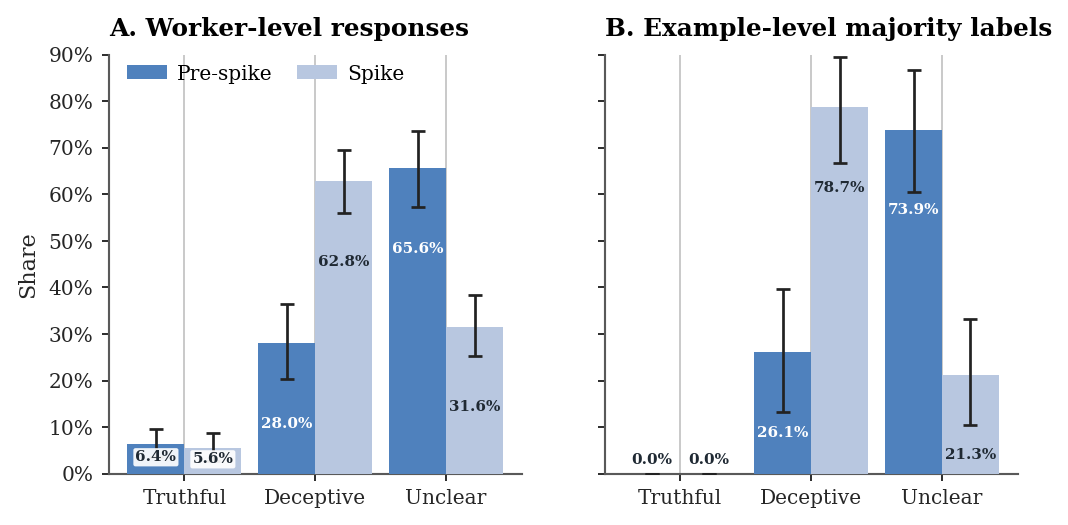

In [4]:
taska_fig1_rows = []

for role_index, role in enumerate(ROLE_ORDER):
    role_label = ROLE_LABELS[role]

    role_worker = taska[taska['pair_role'] == role]
    worker_counts = (
        role_worker.groupby(['task_id', 'response'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=TASKA_RESPONSE_ORDER, fill_value=0)
    )
    worker_boot = bootstrap_counts(worker_counts.to_numpy(), seed=BOOTSTRAP_SEED + 10 * role_index + 1)
    worker_point = worker_counts.sum(axis=0) / worker_counts.to_numpy().sum()
    for label_index, label in enumerate(TASKA_RESPONSE_ORDER):
        ci_low, ci_high = percentile_interval(worker_boot[:, label_index])
        taska_fig1_rows.append({
            'analysis_level': 'Worker-level responses',
            'pair_role': role_label,
            'label': TASKA_RESPONSE_DISPLAY[label],
            'count': int(worker_counts[label].sum()),
            'share': float(worker_point[label]),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'tasks_used': int(role_worker['task_id'].nunique()),
            'tied_tasks_dropped': 0,
        })

    role_consensus = taska_consensus[taska_consensus['pair_role'] == role].copy()
    consensus_matrix = np.column_stack([
        (role_consensus['majority_label'] == label).astype(int).to_numpy()
        for label in TASKA_RESPONSE_ORDER
    ])
    consensus_boot = bootstrap_counts(consensus_matrix, seed=BOOTSTRAP_SEED + 10 * role_index + 2)
    consensus_total = int(consensus_matrix.sum())
    consensus_point = consensus_matrix.sum(axis=0) / consensus_total
    for label_index, label in enumerate(TASKA_RESPONSE_ORDER):
        ci_low, ci_high = percentile_interval(consensus_boot[:, label_index])
        taska_fig1_rows.append({
            'analysis_level': 'Example-level majority labels',
            'pair_role': role_label,
            'label': TASKA_RESPONSE_DISPLAY[label],
            'count': int(consensus_matrix[:, label_index].sum()),
            'share': float(consensus_point[label_index]),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'tasks_used': consensus_total,
            'tied_tasks_dropped': int(role_consensus['tie_dropped'].sum()),
        })

taska_fig1_table = pd.DataFrame(taska_fig1_rows)
taska_fig1_table['analysis_level'] = pd.Categorical(
    taska_fig1_table['analysis_level'],
    categories=['Worker-level responses', 'Example-level majority labels'],
    ordered=True,
)
taska_fig1_table['pair_role'] = pd.Categorical(taska_fig1_table['pair_role'], categories=ROLE_DISPLAY_ORDER, ordered=True)
taska_fig1_table['label'] = pd.Categorical(taska_fig1_table['label'], categories=TASKA_RESPONSE_DISPLAY_ORDER, ordered=True)
taska_fig1_table = taska_fig1_table.sort_values(['analysis_level', 'pair_role', 'label']).reset_index(drop=True)
save_table(taska_fig1_table, 'taska_figure1_response_shares_table')

taska_fig1_display = taska_fig1_table.assign(
    **{
        'Share (%)': lambda df: (100 * df['share']).round(1),
        '95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['ci_low'], df['ci_high'])],
    }
)[[
    'analysis_level', 'pair_role', 'label', 'count', 'tasks_used', 'tied_tasks_dropped', 'Share (%)', '95% CI (%)'
]].rename(columns={
    'analysis_level': 'Analysis level',
    'pair_role': 'Pair role',
    'label': 'Label',
    'count': 'Count',
    'tasks_used': 'Tasks used',
    'tied_tasks_dropped': 'Tied tasks dropped',
})
display(taska_fig1_display)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES['double_tall'], sharey=True)
x_positions = np.arange(len(TASKA_RESPONSE_DISPLAY_ORDER))
bar_width = 0.435
panel_order = ['Worker-level responses', 'Example-level majority labels']

for axis_index, (ax, panel_name) in enumerate(zip(axes, panel_order)):
    panel_table = taska_fig1_table[taska_fig1_table['analysis_level'] == panel_name]
    bar_specs = []
    for role_offset, role in enumerate(ROLE_ORDER):
        role_label = ROLE_LABELS[role]
        role_table = (
            panel_table[panel_table['pair_role'] == role_label]
            .set_index('label')
            .reindex(TASKA_RESPONSE_DISPLAY_ORDER)
            .reset_index()
        )
        bar_positions = x_positions + (role_offset - 0.5) * bar_width
        bars = ax.bar(bar_positions, role_table['share'], width=bar_width, color=ROLE_COLORS[role], label=role_label, zorder=3, hatch=ROLE_HATCHES[role])
        bar_specs.append((bars, role_table['share'].to_numpy()))
        for idx, row in role_table.iterrows():
            add_interval(ax, bar_positions[idx], row['share'], row['ci_low'], row['ci_high'])

    panel_title = 'A. Worker-level responses' if axis_index == 0 else 'B. Example-level majority labels'
    setup_percent_panel(ax, panel_title, ylabel='Share' if axis_index == 0 else None, ylim=(0, 0.90))
    ax.set_xticks(x_positions)
    ax.set_xticklabels(TASKA_RESPONSE_DISPLAY_ORDER)
    for bars, values in bar_specs:
        annotate_bars(ax, bars, values=values, decimals=1, inside_margin_fraction=0.175)

axes[0].legend(loc='upper left', bbox_to_anchor=(0.0, 1.02), ncols=2, columnspacing=1.2, handletextpad=0.5)
save_figure(fig, 'taska_figure1_response_shares')
plt.show()
plt.close(fig)

## Task A validation summary aligned with the paper text

This table reports the two quantities emphasized in the writeup: commitment rate and action accuracy, for both the worker-level annotations and the untied majority-vote labels. It also reports the spike minus pre-spike jump for each metric.

In [5]:
taska_validation_rows = []

for level_name, df, commit_num, commit_den, acc_num, acc_den in [
    ('Worker-level', taska_worker_task, 'committed', 'total', 'correct', 'committed'),
    ('Majority-vote', taska_consensus, 'committed', 'untied_used', 'correct', 'committed'),
]:
    pre_df = df[df['pair_role'] == 'pre_spike'].copy()
    spike_df = df[df['pair_role'] == 'spike'].copy()

    commit_pre, commit_pre_low, commit_pre_high = ratio_summary(pre_df, commit_num, commit_den, seed=BOOTSTRAP_SEED + 1000)
    commit_spike, commit_spike_low, commit_spike_high = ratio_summary(spike_df, commit_num, commit_den, seed=BOOTSTRAP_SEED + 1001)
    commit_diff_boot = bootstrap_diff(pre_df[commit_num].to_numpy(), pre_df[commit_den].to_numpy(), spike_df[commit_num].to_numpy(), spike_df[commit_den].to_numpy(), seed=BOOTSTRAP_SEED + 1002)
    commit_diff_low, commit_diff_high = percentile_interval(commit_diff_boot)

    acc_pre, acc_pre_low, acc_pre_high = ratio_summary(pre_df, acc_num, acc_den, seed=BOOTSTRAP_SEED + 1003)
    acc_spike, acc_spike_low, acc_spike_high = ratio_summary(spike_df, acc_num, acc_den, seed=BOOTSTRAP_SEED + 1004)
    acc_diff_boot = bootstrap_diff(pre_df[acc_num].to_numpy(), pre_df[acc_den].to_numpy(), spike_df[acc_num].to_numpy(), spike_df[acc_den].to_numpy(), seed=BOOTSTRAP_SEED + 1005)
    acc_diff_low, acc_diff_high = percentile_interval(acc_diff_boot)

    taska_validation_rows.append({
        'level': level_name,
        'metric': 'Commitment rate',
        'pre_spike': commit_pre,
        'pre_low': commit_pre_low,
        'pre_high': commit_pre_high,
        'spike': commit_spike,
        'spike_low': commit_spike_low,
        'spike_high': commit_spike_high,
        'delta': commit_spike - commit_pre,
        'delta_low': commit_diff_low,
        'delta_high': commit_diff_high,
    })
    taska_validation_rows.append({
        'level': level_name,
        'metric': 'Action accuracy',
        'pre_spike': acc_pre,
        'pre_low': acc_pre_low,
        'pre_high': acc_pre_high,
        'spike': acc_spike,
        'spike_low': acc_spike_low,
        'spike_high': acc_spike_high,
        'delta': acc_spike - acc_pre,
        'delta_low': acc_diff_low,
        'delta_high': acc_diff_high,
    })

taska_validation_table = pd.DataFrame(taska_validation_rows)
save_table(taska_validation_table, 'taska_validation_summary_table')

taska_validation_display = taska_validation_table.assign(
    **{
        'Pre-spike (%)': lambda df: (100 * df['pre_spike']).round(1),
        'Pre-spike 95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['pre_low'], df['pre_high'])],
        'Spike (%)': lambda df: (100 * df['spike']).round(1),
        'Spike 95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['spike_low'], df['spike_high'])],
        'Spike - Pre (%)': lambda df: (100 * df['delta']).round(1),
        'Delta 95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['delta_low'], df['delta_high'])],
    }
)[[
    'level', 'metric', 'Pre-spike (%)', 'Pre-spike 95% CI (%)', 'Spike (%)', 'Spike 95% CI (%)', 'Spike - Pre (%)', 'Delta 95% CI (%)'
]].rename(columns={
    'level': 'Level',
    'metric': 'Metric',
})
display(taska_validation_display)

,Level,Metric,Pre-spike (%),Pre-spike 95% CI (%),Spike (%),Spike 95% CI (%),Spike - Pre (%),Delta 95% CI (%)
0,Worker-level,Commitment rate,34.400,"[26.4, 43.6]",68.400,"[61.6, 74.8]",34.000,"[23.2, 44.8]"
1,Worker-level,Action accuracy,18.600,"[10.8, 28.2]",91.800,"[87.2, 95.9]",73.200,"[62.7, 81.9]"
2,Majority-vote,Commitment rate,26.100,"[13.9, 39.5]",78.700,"[66.0, 89.6]",52.600,"[34.6, 69.6]"
3,Majority-vote,Action accuracy,0.000,"[0.0, 0.0]",100.000,"[100.0, 100.0]",100.000,"[100.0, 100.0]"


## Task A Figure 4. Model breakdown by pair role

This additional figure breaks Task A down by model and pair role for worker-level `Unclear` rate and worker-call accuracy.

,Metric,Model,Pair role,Count used,Value (%),95% CI (%)
0,Unclear rate,Qwen-7B,Pre-spike,65,58.500,"[41.5, 75.4]"
1,Unclear rate,Qwen-7B,Spike,65,12.300,"[6.2, 20.0]"
2,Unclear rate,Qwen-14B,Pre-spike,65,72.300,"[56.9, 86.2]"
3,Unclear rate,Qwen-14B,Spike,65,35.400,"[23.1, 49.2]"
4,Unclear rate,Llama-8B,Pre-spike,60,51.700,"[33.3, 70.0]"
5,Unclear rate,Llama-8B,Spike,60,35.000,"[23.3, 46.7]"
6,Unclear rate,GPT-OSS-20B,Pre-spike,60,80.000,"[66.7, 91.7]"
7,Unclear rate,GPT-OSS-20B,Spike,60,45.000,"[33.3, 56.7]"
8,Worker accuracy,Qwen-7B,Pre-spike,27,14.800,"[4.0, 27.3]"
9,Worker accuracy,Qwen-7B,Spike,57,91.200,"[82.8, 98.2]"


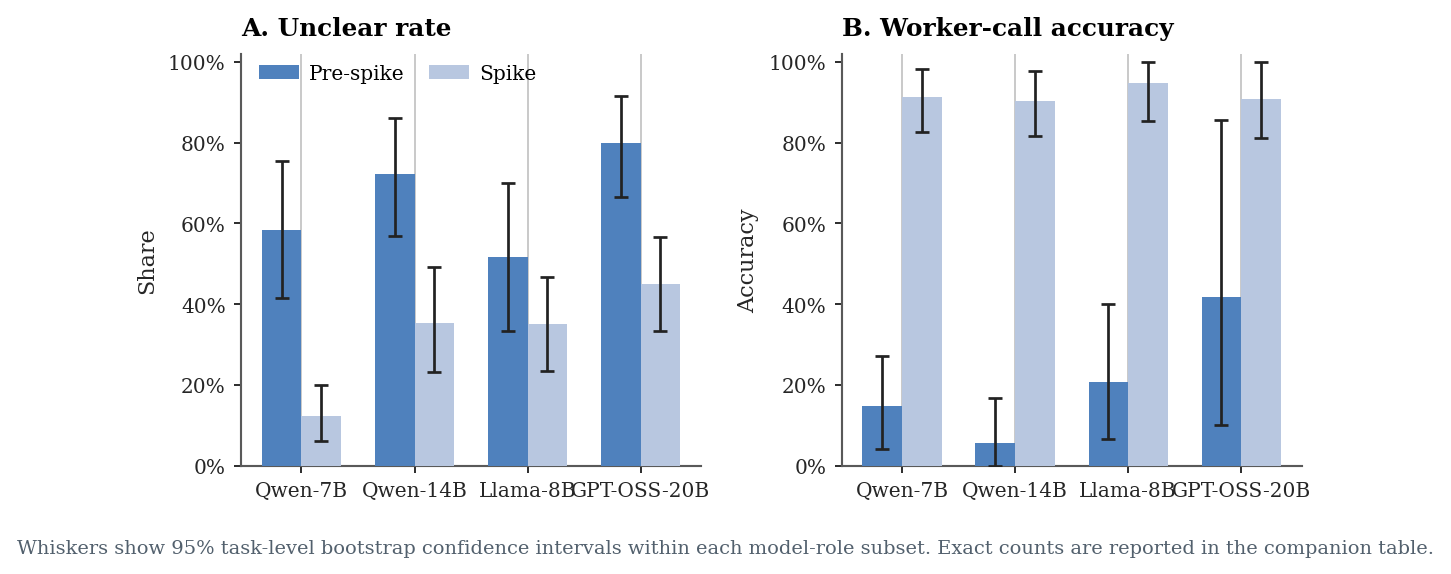

In [6]:
taska_fig4_rows = []

for model_index, model in enumerate(MODEL_ORDER):
    model_label = MODEL_LABELS[model]
    for role_index, role in enumerate(ROLE_ORDER):
        role_label = ROLE_LABELS[role]
        subset = taska_worker_task[(taska_worker_task['model_id'] == model) & (taska_worker_task['pair_role'] == role)].copy()
        unclear_point, unclear_low, unclear_high = ratio_summary(subset, 'unclear', 'total', seed=BOOTSTRAP_SEED + 1300 + 10 * model_index + role_index)
        accuracy_point, accuracy_low, accuracy_high = ratio_summary(subset, 'correct', 'committed', seed=BOOTSTRAP_SEED + 1400 + 10 * model_index + role_index)
        taska_fig4_rows.append({
            'metric': 'Unclear rate',
            'model': model_label,
            'pair_role': role_label,
            'count': int(subset['total'].sum()),
            'value': unclear_point,
            'ci_low': unclear_low,
            'ci_high': unclear_high,
        })
        taska_fig4_rows.append({
            'metric': 'Worker accuracy',
            'model': model_label,
            'pair_role': role_label,
            'count': int(subset['committed'].sum()),
            'value': accuracy_point,
            'ci_low': accuracy_low,
            'ci_high': accuracy_high,
        })

taska_fig4_table = pd.DataFrame(taska_fig4_rows)
taska_fig4_table['metric'] = pd.Categorical(taska_fig4_table['metric'], categories=['Unclear rate', 'Worker accuracy'], ordered=True)
taska_fig4_table['model'] = pd.Categorical(taska_fig4_table['model'], categories=MODEL_DISPLAY_ORDER, ordered=True)
taska_fig4_table['pair_role'] = pd.Categorical(taska_fig4_table['pair_role'], categories=ROLE_DISPLAY_ORDER, ordered=True)
taska_fig4_table = taska_fig4_table.sort_values(['metric', 'model', 'pair_role']).reset_index(drop=True)
save_table(taska_fig4_table, 'taska_figure4_model_role_breakdown_table')

taska_fig4_display = taska_fig4_table.assign(
    **{
        'Value (%)': lambda df: (100 * df['value']).round(1),
        '95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['ci_low'], df['ci_high'])],
    }
)[[
    'metric', 'model', 'pair_role', 'count', 'Value (%)', '95% CI (%)'
]].rename(columns={
    'metric': 'Metric',
    'model': 'Model',
    'pair_role': 'Pair role',
    'count': 'Count used',
})
display(taska_fig4_display)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES['double_wide'], sharey=False)
x_positions = np.arange(len(MODEL_DISPLAY_ORDER))
bar_width = 0.35

for axis_index, metric_name in enumerate(['Unclear rate', 'Worker accuracy']):
    ax = axes[axis_index]
    metric_table = taska_fig4_table[taska_fig4_table['metric'] == metric_name]
    bar_specs = []
    for role_offset, role in enumerate(ROLE_ORDER):
        role_label = ROLE_LABELS[role]
        role_table = (
            metric_table[metric_table['pair_role'] == role_label]
            .set_index('model')
            .reindex(MODEL_DISPLAY_ORDER)
            .reset_index()
        )
        bar_positions = x_positions + (role_offset - 0.5) * bar_width
        bars = ax.bar(bar_positions, role_table['value'], width=bar_width, color=ROLE_COLORS[role], label=role_label, zorder=3, hatch=ROLE_HATCHES[role])
        bar_specs.append((bars, role_table['value'].to_numpy()))
        for idx, row in role_table.iterrows():
            add_interval(ax, bar_positions[idx], row['value'], row['ci_low'], row['ci_high'])

    panel_title = 'A. Unclear rate' if axis_index == 0 else 'B. Worker-call accuracy'
    setup_percent_panel(ax, panel_title, ylabel='Share' if axis_index == 0 else 'Accuracy', ylim=(0, 1.02))
    ax.set_xticks(x_positions)
    ax.set_xticklabels(MODEL_DISPLAY_ORDER)
    #for bars, values in bar_specs:
    #    annotate_bars(ax, bars, values=values, decimals=1)

axes[0].legend(loc='upper left', bbox_to_anchor=(0.0, 1.02), ncols=2, columnspacing=1.2, handletextpad=0.5)
finalize_figure(fig, 'Whiskers show 95% task-level bootstrap confidence intervals within each model-role subset. Exact counts are reported in the companion table.')
save_figure(fig, 'taska_figure4_model_role_breakdown')
plt.show()
plt.close(fig)

## Task B Figure 1. Fraction `Unclear` vs. all other options

Panel A reports all worker responses after collapsing them to `Localized` vs. `Unclear`. Panel B applies the same binary collapse after majority voting at the task level. Tied majority votes are dropped.

In [7]:
# Old Task B unclear/localized figure removed in favor of the consolidated Task B figure below.

## Task B Figure 2. Localization accuracy

The worker-level accuracy is shown on the left and the majority-vote accuracy is shown on the right. Both use exact sentence match. Worker accuracy drops `Unclear` responses, while majority-vote accuracy additionally drops tied majority votes.

In [8]:
# Old Task B localization-accuracy figure removed in favor of the consolidated Task B figure below.

## Task B diagnostics aligned with the paper text

This table reports the additional full-trace localization metrics discussed in the writeup: exact match, within-one-sentence accuracy, mean absolute sentence distance, `No clear decision yet` rate, and inter-annotator agreement.

,Metric,Level,Tasks total,Tasks used,Tied tasks dropped,Numerator count,Denominator count,Value (%),95% CI (%)
0,Unclear rate,Worker-level,100,100,0,171,500,34.200,"[29.0, 39.8]"
1,Unclear rate,Majority-vote,100,95,5,32,95,33.700,"[24.5, 43.3]"
2,Localization accuracy,Worker-level,100,100,0,255,329,77.500,"[71.7, 83.0]"
3,Localization accuracy,Majority-vote,100,95,5,61,63,96.800,"[91.9, 100.0]"


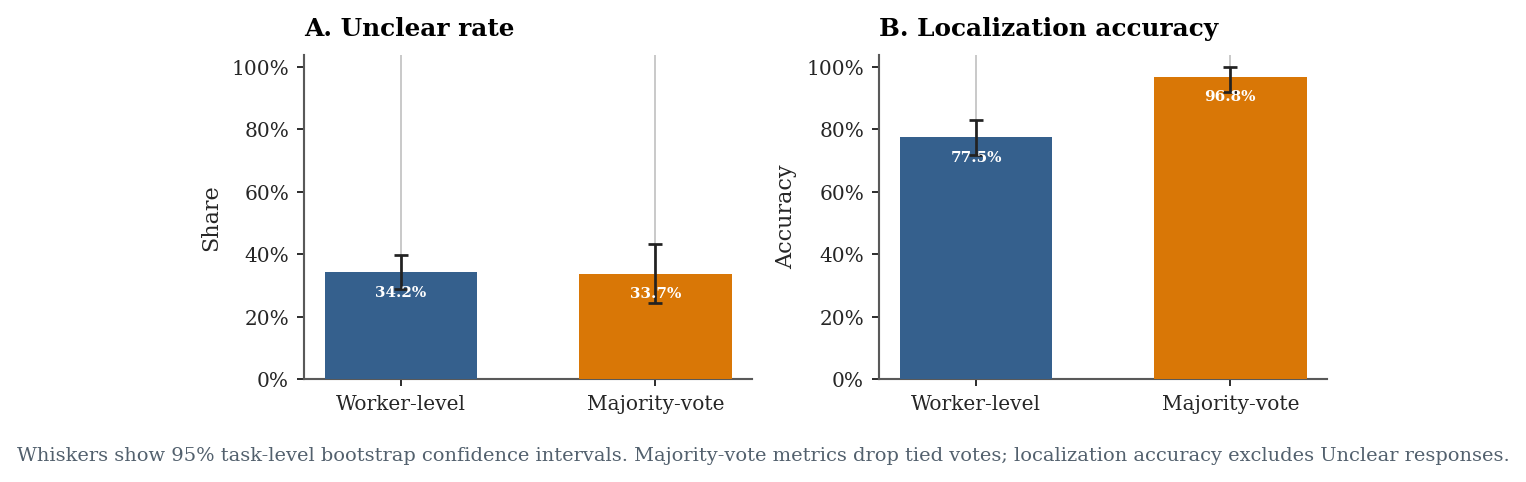

In [9]:
taskb_worker_unclear, taskb_worker_unclear_low, taskb_worker_unclear_high = ratio_summary(taskb_worker_task, 'unclear', 'total', seed=BOOTSTRAP_SEED + 1500)
taskb_majority_unclear, taskb_majority_unclear_low, taskb_majority_unclear_high = ratio_summary(taskb_exact_majority, 'unclear_majority', 'untied_used', seed=BOOTSTRAP_SEED + 1501)
taskb_worker_exact, taskb_worker_exact_low, taskb_worker_exact_high = ratio_summary(taskb_worker_task, 'exact', 'answered', seed=BOOTSTRAP_SEED + 1502)
taskb_majority_exact, taskb_majority_exact_low, taskb_majority_exact_high = ratio_summary(taskb_exact_majority, 'exact', 'answered', seed=BOOTSTRAP_SEED + 1503)

taskb_summary_table = pd.DataFrame([
    {
        'metric': 'Unclear rate',
        'level': 'Worker-level',
        'tasks_total': len(taskb_worker_task),
        'tasks_used': len(taskb_worker_task),
        'tied_tasks_dropped': 0,
        'numerator_count': int(taskb_worker_task['unclear'].sum()),
        'denominator_count': int(taskb_worker_task['total'].sum()),
        'value': taskb_worker_unclear,
        'ci_low': taskb_worker_unclear_low,
        'ci_high': taskb_worker_unclear_high,
    },
    {
        'metric': 'Unclear rate',
        'level': 'Majority-vote',
        'tasks_total': len(taskb_exact_majority),
        'tasks_used': int(taskb_exact_majority['untied_used'].sum()),
        'tied_tasks_dropped': int(taskb_exact_majority['tie_dropped'].sum()),
        'numerator_count': int(taskb_exact_majority['unclear_majority'].sum()),
        'denominator_count': int(taskb_exact_majority['untied_used'].sum()),
        'value': taskb_majority_unclear,
        'ci_low': taskb_majority_unclear_low,
        'ci_high': taskb_majority_unclear_high,
    },
    {
        'metric': 'Localization accuracy',
        'level': 'Worker-level',
        'tasks_total': len(taskb_worker_task),
        'tasks_used': len(taskb_worker_task),
        'tied_tasks_dropped': 0,
        'numerator_count': int(taskb_worker_task['exact'].sum()),
        'denominator_count': int(taskb_worker_task['answered'].sum()),
        'value': taskb_worker_exact,
        'ci_low': taskb_worker_exact_low,
        'ci_high': taskb_worker_exact_high,
    },
    {
        'metric': 'Localization accuracy',
        'level': 'Majority-vote',
        'tasks_total': len(taskb_exact_majority),
        'tasks_used': int(taskb_exact_majority['untied_used'].sum()),
        'tied_tasks_dropped': int(taskb_exact_majority['tie_dropped'].sum()),
        'numerator_count': int(taskb_exact_majority['exact'].sum()),
        'denominator_count': int(taskb_exact_majority['answered'].sum()),
        'value': taskb_majority_exact,
        'ci_low': taskb_majority_exact_low,
        'ci_high': taskb_majority_exact_high,
    },
])

taskb_summary_table['metric'] = pd.Categorical(
    taskb_summary_table['metric'],
    categories=['Unclear rate', 'Localization accuracy'],
    ordered=True,
)
taskb_summary_table['level'] = pd.Categorical(
    taskb_summary_table['level'],
    categories=['Worker-level', 'Majority-vote'],
    ordered=True,
)
taskb_summary_table = taskb_summary_table.sort_values(['metric', 'level']).reset_index(drop=True)
save_table(taskb_summary_table, 'taskb_figure1_worker_vs_majority_summary_table')

taskb_summary_display = taskb_summary_table.assign(
    **{
        'Value (%)': lambda df: (100 * df['value']).round(1),
        '95% CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['ci_low'], df['ci_high'])],
    }
)[[
    'metric', 'level', 'tasks_total', 'tasks_used', 'tied_tasks_dropped', 'numerator_count', 'denominator_count', 'Value (%)', '95% CI (%)'
]].rename(columns={
    'metric': 'Metric',
    'level': 'Level',
    'tasks_total': 'Tasks total',
    'tasks_used': 'Tasks used',
    'tied_tasks_dropped': 'Tied tasks dropped',
    'numerator_count': 'Numerator count',
    'denominator_count': 'Denominator count',
})
display(taskb_summary_display)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES['double'], sharey=False)
level_order = ['Worker-level', 'Majority-vote']
level_colors = {'Worker-level': COLORS['blue'], 'Majority-vote': COLORS['orange']}

for axis_index, metric_name in enumerate(['Unclear rate', 'Localization accuracy']):
    ax = axes[axis_index]
    metric_table = (
        taskb_summary_table[taskb_summary_table['metric'] == metric_name]
        .set_index('level')
        .reindex(level_order)
        .reset_index()
    )
    x_positions = np.arange(len(metric_table))
    bars = ax.bar(
        x_positions,
        metric_table['value'],
        width=0.6,
        color=[level_colors[level] for level in metric_table['level']],
        zorder=3,
    )
    for idx, row in metric_table.iterrows():
        add_interval(ax, x_positions[idx], row['value'], row['ci_low'], row['ci_high'])

    panel_title = 'A. Unclear rate' if axis_index == 0 else 'B. Localization accuracy'
    y_label = 'Share' if axis_index == 0 else 'Accuracy'
    setup_percent_panel(ax, panel_title, ylabel=y_label, ylim=(0, 1.04))
    ax.set_xticks(x_positions)
    ax.set_xticklabels(level_order)
    annotate_bars(ax, bars, values=metric_table['value'].to_numpy(), decimals=1)

finalize_figure(fig, 'Whiskers show 95% task-level bootstrap confidence intervals. Majority-vote metrics drop tied votes; localization accuracy excludes Unclear responses.')
save_figure(fig, 'taskb_figure1_worker_vs_majority_summary')
plt.show()
plt.close(fig)

## Task B Figure 3. Model breakdown

Since all Task B rows are spike tasks, this breakdown is by model only. The left panel reports the worker-level `Unclear` rate and the right panel reports worker localization accuracy.

In [10]:
# Task B figure consolidated above.

## Appendix-ready model breakdown tables

These tables collect the model-level breakdowns in a compact appendix-friendly format with confidence intervals.

In [11]:
appendix_taska_rows = []
for model_index, model in enumerate(MODEL_ORDER):
    model_label = MODEL_LABELS[model]
    for role_index, role in enumerate(ROLE_ORDER):
        role_label = ROLE_LABELS[role]
        worker_subset = taska_worker_task[(taska_worker_task['model_id'] == model) & (taska_worker_task['pair_role'] == role)].copy()
        majority_subset = taska_consensus[(taska_consensus['model_id'] == model) & (taska_consensus['pair_role'] == role)].copy()

        worker_commitment, worker_commitment_low, worker_commitment_high = ratio_summary(worker_subset, 'committed', 'total', seed=BOOTSTRAP_SEED + 2000 + 20 * model_index + role_index)
        worker_unclear, worker_unclear_low, worker_unclear_high = ratio_summary(worker_subset, 'unclear', 'total', seed=BOOTSTRAP_SEED + 2001 + 20 * model_index + role_index)
        worker_accuracy, worker_accuracy_low, worker_accuracy_high = ratio_summary(worker_subset, 'correct', 'committed', seed=BOOTSTRAP_SEED + 2002 + 20 * model_index + role_index)
        majority_commitment, majority_commitment_low, majority_commitment_high = ratio_summary(majority_subset, 'committed', 'untied_used', seed=BOOTSTRAP_SEED + 2003 + 20 * model_index + role_index)
        majority_unclear, majority_unclear_low, majority_unclear_high = ratio_summary(majority_subset, 'unclear_majority', 'untied_used', seed=BOOTSTRAP_SEED + 2004 + 20 * model_index + role_index)
        majority_accuracy, majority_accuracy_low, majority_accuracy_high = ratio_summary(majority_subset, 'correct', 'committed', seed=BOOTSTRAP_SEED + 2005 + 20 * model_index + role_index)

        appendix_taska_rows.append({
            'model': model_label,
            'pair_role': role_label,
            'tasks_total': len(majority_subset),
            'untied_tasks_used': int(majority_subset['untied_used'].sum()),
            'tied_tasks_dropped': int(majority_subset['tie_dropped'].sum()),
            'worker_commitment_rate': worker_commitment,
            'worker_commitment_low': worker_commitment_low,
            'worker_commitment_high': worker_commitment_high,
            'worker_unclear_rate': worker_unclear,
            'worker_unclear_low': worker_unclear_low,
            'worker_unclear_high': worker_unclear_high,
            'worker_action_accuracy': worker_accuracy,
            'worker_action_accuracy_low': worker_accuracy_low,
            'worker_action_accuracy_high': worker_accuracy_high,
            'majority_commitment_rate': majority_commitment,
            'majority_commitment_low': majority_commitment_low,
            'majority_commitment_high': majority_commitment_high,
            'majority_unclear_rate': majority_unclear,
            'majority_unclear_low': majority_unclear_low,
            'majority_unclear_high': majority_unclear_high,
            'majority_action_accuracy': majority_accuracy,
            'majority_action_accuracy_low': majority_accuracy_low,
            'majority_action_accuracy_high': majority_accuracy_high,
        })

appendix_taska_table = pd.DataFrame(appendix_taska_rows)
appendix_taska_table['model'] = pd.Categorical(appendix_taska_table['model'], categories=MODEL_DISPLAY_ORDER, ordered=True)
appendix_taska_table['pair_role'] = pd.Categorical(appendix_taska_table['pair_role'], categories=ROLE_DISPLAY_ORDER, ordered=True)
appendix_taska_table = appendix_taska_table.sort_values(['model', 'pair_role']).reset_index(drop=True)
save_table(appendix_taska_table, 'appendix_taska_model_breakdown_table')

appendix_taska_display = appendix_taska_table.assign(
    **{
        'Worker commitment (%)': lambda df: (100 * df['worker_commitment_rate']).round(1),
        'Worker commitment CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_commitment_low'], df['worker_commitment_high'])],
        'Worker unclear (%)': lambda df: (100 * df['worker_unclear_rate']).round(1),
        'Worker unclear CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_unclear_low'], df['worker_unclear_high'])],
        'Worker accuracy (%)': lambda df: (100 * df['worker_action_accuracy']).round(1),
        'Worker accuracy CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_action_accuracy_low'], df['worker_action_accuracy_high'])],
        'Majority commitment (%)': lambda df: (100 * df['majority_commitment_rate']).round(1),
        'Majority commitment CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['majority_commitment_low'], df['majority_commitment_high'])],
        'Majority unclear (%)': lambda df: (100 * df['majority_unclear_rate']).round(1),
        'Majority unclear CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['majority_unclear_low'], df['majority_unclear_high'])],
        'Majority accuracy (%)': lambda df: (100 * df['majority_action_accuracy']).round(1),
        'Majority accuracy CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['majority_action_accuracy_low'], df['majority_action_accuracy_high'])],
    }
)[[
    'model', 'pair_role', 'tasks_total', 'untied_tasks_used', 'tied_tasks_dropped', 'Worker commitment (%)', 'Worker commitment CI (%)', 'Worker accuracy (%)', 'Worker accuracy CI (%)', 'Majority commitment (%)', 'Majority commitment CI (%)', 'Majority accuracy (%)', 'Majority accuracy CI (%)'
]].rename(columns={
    'model': 'Model',
    'pair_role': 'Pair role',
    'tasks_total': 'Tasks total',
    'untied_tasks_used': 'Untied tasks used',
    'tied_tasks_dropped': 'Tied tasks dropped',
})
display(appendix_taska_display)

appendix_taskb_rows = []
for model_index, model in enumerate(MODEL_ORDER):
    model_label = MODEL_LABELS[model]
    worker_subset = taskb_worker_task[taskb_worker_task['model_id'] == model].copy()
    majority_subset = taskb_exact_majority[taskb_exact_majority['model_id'] == model].copy()
    pair_subset = taskb_pairwise[taskb_pairwise['model_id'] == model].copy()

    worker_unclear, worker_unclear_low, worker_unclear_high = ratio_summary(worker_subset, 'unclear', 'total', seed=BOOTSTRAP_SEED + 2100 + model_index)
    worker_exact, worker_exact_low, worker_exact_high = ratio_summary(worker_subset, 'exact', 'answered', seed=BOOTSTRAP_SEED + 2101 + model_index)
    worker_within1, worker_within1_low, worker_within1_high = ratio_summary(worker_subset, 'within1', 'answered', seed=BOOTSTRAP_SEED + 2102 + model_index)
    worker_distance, worker_distance_low, worker_distance_high = ratio_summary(worker_subset, 'distance_sum', 'answered', seed=BOOTSTRAP_SEED + 2103 + model_index)
    pairwise_point, pairwise_low, pairwise_high = ratio_summary(pair_subset, 'agree_pairs', 'total_pairs', seed=BOOTSTRAP_SEED + 2104 + model_index)
    majority_unclear, majority_unclear_low, majority_unclear_high = ratio_summary(majority_subset, 'unclear_majority', 'untied_used', seed=BOOTSTRAP_SEED + 2105 + model_index)
    majority_exact, majority_exact_low, majority_exact_high = ratio_summary(majority_subset, 'exact', 'answered', seed=BOOTSTRAP_SEED + 2106 + model_index)
    majority_within1, majority_within1_low, majority_within1_high = ratio_summary(majority_subset, 'within1', 'answered', seed=BOOTSTRAP_SEED + 2107 + model_index)
    majority_distance, majority_distance_low, majority_distance_high = ratio_summary(majority_subset, 'distance_sum', 'answered', seed=BOOTSTRAP_SEED + 2108 + model_index)

    appendix_taskb_rows.append({
        'model': model_label,
        'tasks_total': len(majority_subset),
        'untied_tasks_used': int(majority_subset['untied_used'].sum()),
        'tied_tasks_dropped': int(majority_subset['tie_dropped'].sum()),
        'worker_unclear_rate': worker_unclear,
        'worker_unclear_low': worker_unclear_low,
        'worker_unclear_high': worker_unclear_high,
        'worker_exact_match': worker_exact,
        'worker_exact_low': worker_exact_low,
        'worker_exact_high': worker_exact_high,
        'worker_within_one': worker_within1,
        'worker_within1_low': worker_within1_low,
        'worker_within1_high': worker_within1_high,
        'worker_mean_abs_distance': worker_distance,
        'worker_distance_low': worker_distance_low,
        'worker_distance_high': worker_distance_high,
        'pairwise_agreement': pairwise_point,
        'pairwise_low': pairwise_low,
        'pairwise_high': pairwise_high,
        'majority_unclear_rate': majority_unclear,
        'majority_unclear_low': majority_unclear_low,
        'majority_unclear_high': majority_unclear_high,
        'majority_exact_match': majority_exact,
        'majority_exact_low': majority_exact_low,
        'majority_exact_high': majority_exact_high,
        'majority_within_one': majority_within1,
        'majority_within1_low': majority_within1_low,
        'majority_within1_high': majority_within1_high,
        'majority_mean_abs_distance': majority_distance,
        'majority_distance_low': majority_distance_low,
        'majority_distance_high': majority_distance_high,
    })

appendix_taskb_table = pd.DataFrame(appendix_taskb_rows)
appendix_taskb_table['model'] = pd.Categorical(appendix_taskb_table['model'], categories=MODEL_DISPLAY_ORDER, ordered=True)
appendix_taskb_table = appendix_taskb_table.sort_values('model').reset_index(drop=True)
save_table(appendix_taskb_table, 'appendix_taskb_model_breakdown_table')

appendix_taskb_display = appendix_taskb_table.assign(
    **{
        'Worker unclear (%)': lambda df: (100 * df['worker_unclear_rate']).round(1),
        'Worker unclear CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_unclear_low'], df['worker_unclear_high'])],
        'Worker exact (%)': lambda df: (100 * df['worker_exact_match']).round(1),
        'Worker exact CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_exact_low'], df['worker_exact_high'])],
        'Worker within 1 (%)': lambda df: (100 * df['worker_within_one']).round(1),
        'Worker within-1 CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['worker_within1_low'], df['worker_within1_high'])],
        'Worker abs. dist.': lambda df: df['worker_mean_abs_distance'].round(3),
        'Worker dist. CI': lambda df: [format_num_ci(low, high) for low, high in zip(df['worker_distance_low'], df['worker_distance_high'])],
        'Pairwise agreement (%)': lambda df: (100 * df['pairwise_agreement']).round(1),
        'Pairwise CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['pairwise_low'], df['pairwise_high'])],
        'Majority exact (%)': lambda df: (100 * df['majority_exact_match']).round(1),
        'Majority exact CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['majority_exact_low'], df['majority_exact_high'])],
        'Majority within 1 (%)': lambda df: (100 * df['majority_within_one']).round(1),
        'Majority within-1 CI (%)': lambda df: [format_pct_ci(low, high) for low, high in zip(df['majority_within1_low'], df['majority_within1_high'])],
        'Majority abs. dist.': lambda df: df['majority_mean_abs_distance'].round(3),
        'Majority dist. CI': lambda df: [format_num_ci(low, high) for low, high in zip(df['majority_distance_low'], df['majority_distance_high'])],
    }
)[[
    'model', 'tasks_total', 'untied_tasks_used', 'tied_tasks_dropped', 'Worker unclear (%)', 'Worker exact (%)', 'Worker within 1 (%)', 'Worker abs. dist.', 'Pairwise agreement (%)', 'Majority exact (%)', 'Majority within 1 (%)', 'Majority abs. dist.'
]].rename(columns={
    'model': 'Model',
    'tasks_total': 'Tasks total',
    'untied_tasks_used': 'Untied tasks used',
    'tied_tasks_dropped': 'Tied tasks dropped',
})
display(appendix_taskb_display)

/tmp/ipykernel_1720986/1536939236.py:22: RuntimeWarning: invalid value encountered in divide
  ratio = numerator_sum / denominator_sum


,Model,Pair role,Tasks total,Untied tasks used,Tied tasks dropped,Worker commitment (%),Worker commitment CI (%),Worker accuracy (%),Worker accuracy CI (%),Majority commitment (%),Majority commitment CI (%),Majority accuracy (%),Majority accuracy CI (%)
0,Qwen-7B,Pre-spike,13,11,2,41.500,"[24.6, 58.5]",14.800,"[4.0, 27.8]",27.300,"[0.0, 55.6]",0.000,"[0.0, 0.0]"
1,Qwen-7B,Spike,13,12,1,87.700,"[80.0, 93.8]",91.200,"[82.1, 98.3]",100.000,"[100.0, 100.0]",100.000,"[100.0, 100.0]"
2,Qwen-14B,Pre-spike,13,12,1,27.700,"[15.3, 41.6]",5.600,"[0.0, 16.7]",16.700,"[0.0, 41.7]",0.000,"[0.0, 0.0]"
3,Qwen-14B,Spike,13,12,1,64.600,"[52.3, 76.9]",90.500,"[81.6, 97.7]",66.700,"[38.5, 91.7]",100.000,"[100.0, 100.0]"
4,Llama-8B,Pre-spike,12,11,1,48.300,"[30.0, 65.0]",20.700,"[6.9, 39.3]",54.500,"[25.0, 83.3]",0.000,"[0.0, 0.0]"
5,Llama-8B,Spike,12,12,0,65.000,"[53.3, 76.7]",94.900,"[85.4, 100.0]",83.300,"[58.3, 100.0]",100.000,"[100.0, 100.0]"
6,GPT-OSS-20B,Pre-spike,12,12,0,20.000,"[8.3, 35.0]",41.700,"[9.5, 83.3]",8.300,"[0.0, 25.0]",0.000,"[0.0, 0.0]"
7,GPT-OSS-20B,Spike,12,11,1,55.000,"[43.3, 66.7]",90.900,"[81.5, 100.0]",63.600,"[33.3, 90.9]",100.000,"[100.0, 100.0]"


,Model,Tasks total,Untied tasks used,Tied tasks dropped,Worker unclear (%),Worker exact (%),Worker within 1 (%),Worker abs. dist.,Pairwise agreement (%),Majority exact (%),Majority within 1 (%),Majority abs. dist.
0,Qwen-7B,25,25,0,41.600,76.700,80.800,0.781,42.400,100.000,100.000,0.000
1,Qwen-14B,25,24,1,29.600,78.400,83.000,1.170,48.800,100.000,100.000,0.000
2,Llama-8B,25,25,0,24.000,88.400,91.600,0.495,52.400,100.000,100.000,0.000
3,GPT-OSS-20B,25,21,4,41.600,63.000,72.600,1.452,52.000,83.300,91.700,0.667


# Task B model-level figure removed; appendix tables remain below.

In [12]:
NL = chr(10)
ROW_END = chr(92) * 2


def latex_pct_ci(value: float, low: float, high: float) -> str:
    return f"\makecell{{\({100 * value:.1f}\) {ROW_END} {{\scriptsize \([{100 * low:.1f},{100 * high:.1f}]\)}}}}"


def taska_row(metric_prefix: str, model: str) -> str:
    pre = appendix_taska_table[(appendix_taska_table['model'] == model) & (appendix_taska_table['pair_role'] == 'Pre-spike')].iloc[0]
    spike = appendix_taska_table[(appendix_taska_table['model'] == model) & (appendix_taska_table['pair_role'] == 'Spike')].iloc[0]
    return (
        f"{model} "
        f"& {latex_pct_ci(pre[f'{metric_prefix}_unclear_rate'], pre[f'{metric_prefix}_unclear_low'], pre[f'{metric_prefix}_unclear_high'])} "
        f"& {latex_pct_ci(spike[f'{metric_prefix}_unclear_rate'], spike[f'{metric_prefix}_unclear_low'], spike[f'{metric_prefix}_unclear_high'])} "
        f"& {latex_pct_ci(pre[f'{metric_prefix}_action_accuracy'], pre[f'{metric_prefix}_action_accuracy_low'], pre[f'{metric_prefix}_action_accuracy_high'])} "
        f"& {latex_pct_ci(spike[f'{metric_prefix}_action_accuracy'], spike[f'{metric_prefix}_action_accuracy_low'], spike[f'{metric_prefix}_action_accuracy_high'])} {ROW_END}"
    )


taska_worker_rows = [taska_row('worker', model) for model in MODEL_DISPLAY_ORDER]
taska_majority_rows = [taska_row('majority', model) for model in MODEL_DISPLAY_ORDER]

taska_paper_table_tex = NL.join([
    r'\begin{table}[t]',
    r'\centering',
    r'\scriptsize',
    r'\setlength{\tabcolsep}{4pt}',
    r'\renewcommand{\arraystretch}{1.35}',
    r'\caption{',
    r'\textbf{Per-model MTurk validation statistics for Task A.}',
    r'For each model, we report worker-level and majority-vote unclear rate and accuracy separately for pre-spike and spike snippets.',
    r'Values are percentages with bootstrap \(95\%\) confidence intervals in brackets. Majority-vote statistics drop tied votes.',
    r'}',
    r'\label{tab:taska_per_model_mturk}',
    r'\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}lcccc@{}}',
    r'\toprule',
    r'& \multicolumn{2}{c}{Unclear rate} & \multicolumn{2}{c}{Accuracy} ' + ROW_END,
    r'\cmidrule(lr){2-3}',
    r'\cmidrule(lr){4-5}',
    r'Model & Pre-spike & Spike & Pre-spike & Spike ' + ROW_END,
    r'\midrule',
    r'\multicolumn{5}{@{}l}{\textbf{Worker-level}} ' + ROW_END,
    *taska_worker_rows,
    r'\addlinespace[2pt]',
    r'\multicolumn{5}{@{}l}{\textbf{Majority-vote}} ' + ROW_END,
    *taska_majority_rows,
    r'\bottomrule',
    r'\end{tabular*}',
    r'\end{table}',
])


taskb_rows = []
for model in MODEL_DISPLAY_ORDER:
    row = appendix_taskb_table[appendix_taskb_table['model'] == model].iloc[0]
    taskb_rows.append(
        f"{model} "
        f"& {latex_pct_ci(row['worker_unclear_rate'], row['worker_unclear_low'], row['worker_unclear_high'])} "
        f"& {latex_pct_ci(row['worker_exact_match'], row['worker_exact_low'], row['worker_exact_high'])} "
        f"& {latex_pct_ci(row['majority_unclear_rate'], row['majority_unclear_low'], row['majority_unclear_high'])} "
        f"& {latex_pct_ci(row['majority_exact_match'], row['majority_exact_low'], row['majority_exact_high'])} {ROW_END}"
    )


taskb_paper_table_tex = NL.join([
    r'\begin{table}[t]',
    r'\centering',
    r'\scriptsize',
    r'\setlength{\tabcolsep}{4pt}',
    r'\renewcommand{\arraystretch}{1.35}',
    r'\caption{',
    r'\textbf{Per-model MTurk validation statistics for Task B.}',
    r'For each model, we report worker-level and majority-vote unclear rate and localization accuracy.',
    r'Values are percentages with bootstrap \(95\%\) confidence intervals in brackets. Majority-vote statistics drop tied votes, and localization accuracy excludes Unclear responses.',
    r'}',
    r'\label{tab:taskb_per_model_mturk}',
    r'\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}lcccc@{}}',
    r'\toprule',
    r'& \multicolumn{2}{c}{Worker-level} & \multicolumn{2}{c}{Majority-vote} ' + ROW_END,
    r'\cmidrule(lr){2-3}',
    r'\cmidrule(lr){4-5}',
    r'Model & Unclear rate & Localization accuracy & Unclear rate & Localization accuracy ' + ROW_END,
    r'\midrule',
    *taskb_rows,
    r'\bottomrule',
    r'\end{tabular*}',
    r'\end{table}',
])

(TABLE_DIR / 'taska_per_model_mturk_table.tex').write_text(taska_paper_table_tex)
(TABLE_DIR / 'taskb_per_model_mturk_table.tex').write_text(taskb_paper_table_tex)

print(taska_paper_table_tex)
print()
print(taskb_paper_table_tex)

\begin{table}[t]
\centering
\scriptsize
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.35}
\caption{
\textbf{Per-model MTurk validation statistics for Task A.}
For each model, we report worker-level and majority-vote unclear rate and accuracy separately for pre-spike and spike snippets.
Values are percentages with bootstrap \(95\%\) confidence intervals in brackets. Majority-vote statistics drop tied votes.
}
\label{tab:taska_per_model_mturk}
\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}lcccc@{}}
\toprule
& \multicolumn{2}{c}{Unclear rate} & \multicolumn{2}{c}{Accuracy} \\
\cmidrule(lr){2-3}
\cmidrule(lr){4-5}
Model & Pre-spike & Spike & Pre-spike & Spike \\
\midrule
\multicolumn{5}{@{}l}{\textbf{Worker-level}} \\
Qwen-7B & \makecell{\(58.5\) \\ {\scriptsize \([40.0,75.4]\)}} & \makecell{\(12.3\) \\ {\scriptsize \([6.2,18.5]\)}} & \makecell{\(14.8\) \\ {\scriptsize \([4.0,27.8]\)}} & \makecell{\(91.2\) \\ {\scriptsize \([82.1,98.3]\)}} \\
Qwen-14B & \makecell{\(72.3

In [13]:
exported_artifacts = pd.DataFrame({
    'Type': ['Figure'] * len(sorted(FIGURE_DIR.glob('*.pdf'))) + ['Figure'] * len(sorted(FIGURE_DIR.glob('*.png'))) + ['Table'] * len(sorted(TABLE_DIR.glob('*.csv'))),
    'Name': [path.name for path in sorted(FIGURE_DIR.glob('*.pdf'))] + [path.name for path in sorted(FIGURE_DIR.glob('*.png'))] + [path.name for path in sorted(TABLE_DIR.glob('*.csv'))],
    'Path': [str(path) for path in sorted(FIGURE_DIR.glob('*.pdf'))] + [str(path) for path in sorted(FIGURE_DIR.glob('*.png'))] + [str(path) for path in sorted(TABLE_DIR.glob('*.csv'))],
})
display(exported_artifacts)

,Type,Name,Path
0,Figure,taska_figure1_response_shares.pdf,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taska_figure1_response_shares.pdf
1,Figure,taska_figure4_model_role_breakdown.pdf,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taska_figure4_model_role_breakdown.pdf
2,Figure,taskb_figure1_worker_vs_majority_summary.pdf,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taskb_figure1_worker_vs_majority_summary.pdf
3,Figure,taska_figure1_response_shares.png,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taska_figure1_response_shares.png
4,Figure,taska_figure4_model_role_breakdown.png,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taska_figure4_model_role_breakdown.png
5,Figure,taskb_figure1_worker_vs_majority_summary.png,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/figures/mturk_results/taskb_figure1_worker_vs_majority_summary.png
6,Table,appendix_taska_model_breakdown_table.csv,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/tables/mturk_results/appendix_taska_model_breakdown_table.csv
7,Table,appendix_taskb_model_breakdown_table.csv,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/tables/mturk_results/appendix_taskb_model_breakdown_table.csv
8,Table,taska_figure1_response_shares_table.csv,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/tables/mturk_results/taska_figure1_response_shares_table.csv
9,Table,taska_figure4_model_role_breakdown_table.csv,/playpen-ssd/smerrill/deception2/Notebooks/mturk/Results/tables/mturk_results/taska_figure4_model_role_breakdown_table.csv
